# Academic Project: ID3 Decision Tree (Scratch Implementation)

This notebook presents a complete implementation of the ID3 algorithm for classifying the Iris dataset, developed entirely from scratch (no dependency on `scikit-learn`).

**Objectives achieved:**
1. Mathematical foundation (Entropy and Information Gain).
2. Algorithm implementation with support for continuous values.
3. Structural visualization of the generated Tree.
4. Rigorous evaluation (Confusion Matrix, Precision, Recall, F1-Score).
5. **Interactive manual testing module** for new samples.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
plt.style.use('ggplot')

## 1. Data Loading and Preparation
Without using external machine learning libraries, we split the dataset into training and testing data.

In [2]:
df = pd.read_csv('iris.csv')
if 'ID' in df.columns:
    df = df.drop('ID', axis=1)

# Manual Train/Test split
def train_test_split(df, test_size=0.2):
    indices = np.random.permutation(df.index)
    t_size = int(len(df) * test_size)
    return df.iloc[indices[t_size:]], df.iloc[indices[:t_size]]

train_df, test_df = train_test_split(df)
X_train, y_train = train_df.drop('class', axis=1).values, train_df['class'].values
X_test, y_test = test_df.drop('class', axis=1).values, test_df['class'].values

print(f"Training: {len(X_train)} samples | Testing: {len(X_test)} samples")

Training: 120 samples | Testing: 30 samples


## 2. Information Theory: Entropy and Information Gain

**Entropy** measures the level of impurity in a node. **Information Gain** assesses how much this impurity is reduced when we split the data based on a specific mathematical feature.

$$H(S) = -\sum p_i \log_2(p_i)$$
$$IG(S, A) = H(S) - \sum \frac{|S_v|}{|S|} H(S_v)$$

In [3]:
def entropy(y):
    # Handle string labels by finding unique values
    classes, counts = np.unique(y, return_counts=True)
    probs = counts / len(y)
    return -np.sum(probs * np.log2(probs + 1e-9))

def information_gain(y, y_left, y_right):
    p_left, p_right = len(y_left) / len(y), len(y_right) / len(y)
    return entropy(y) - (p_left * entropy(y_left) + p_right * entropy(y_right))

## 3. ID3 Algorithm: Recursive Logic
Since the Iris dataset has continuous features (e.g., petal length = 1.4), our ID3 implementation tests all possible values in the feature and chooses the numerical `threshold` that maximizes Information Gain.

In [4]:
class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, *, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value
    def is_leaf(self): return self.value is not None

class ID3Tree:
    def __init__(self, max_depth=10):
        self.max_depth = max_depth
        self.root = None
        self.feature_names = ['sepallength', 'sepalwidth', 'petallength', 'petalwidth']
        
    def fit(self, X, y):
        self.root = self._grow(X, y, 0)
        
    def _grow(self, X, y, depth):
        n_labels = len(np.unique(y))
        # Stopping criteria
        if depth >= self.max_depth or n_labels == 1 or len(y) < 2:
            return Node(value=self._most_common(y))
            
        best_feat, best_thresh = self._best_split(X, y)
        if best_feat is None:
            return Node(value=self._most_common(y))
            
        l_idx = X[:, best_feat] <= best_thresh
        r_idx = X[:, best_feat] > best_thresh
        return Node(feature=best_feat, threshold=best_thresh,
                    left=self._grow(X[l_idx], y[l_idx], depth + 1),
                    right=self._grow(X[r_idx], y[r_idx], depth + 1))
                    
    def _best_split(self, X, y):
        best_gain, split_idx, split_thresh = -1, None, None
        for feat_idx in range(X.shape[1]):
            thresholds = np.unique(X[:, feat_idx])
            for thr in thresholds:
                l_idx, r_idx = X[:, feat_idx] <= thr, X[:, feat_idx] > thr
                if sum(l_idx) == 0 or sum(r_idx) == 0: continue
                gain = information_gain(y, y[l_idx], y[r_idx])
                if gain > best_gain:
                    best_gain, split_idx, split_thresh = gain, feat_idx, thr
        return split_idx, split_thresh
        
    def _most_common(self, y):
        vals, counts = np.unique(y, return_counts=True)
        return vals[np.argmax(counts)]
        
    def predict(self, X):
        return np.array([self._traverse(x, self.root) for x in X])
        
    def _traverse(self, x, node):
        if node.is_leaf(): return node.value
        if x[node.feature] <= node.threshold: return self._traverse(x, node.left)
        return self._traverse(x, node.right)
        
    def print_tree(self, node=None, depth=0):
        node = node or self.root
        if node.is_leaf():
            print('  ' * depth + f"-> Class: {node.value}")
            return
        print('  ' * depth + f"[{self.feature_names[node.feature]} <= {node.threshold:.2f}]")
        self.print_tree(node.left, depth + 1)
        print('  ' * depth + f"[{self.feature_names[node.feature]} > {node.threshold:.2f}]")
        self.print_tree(node.right, depth + 1)


## 4. Model Training and Tree Visualization
We train the model and print the logical path the tree found to classify the flowers. Note how `petalwidth` is often the root node!

In [5]:
tree = ID3Tree(max_depth=5)
tree.fit(X_train, y_train)
print("Generated Decision Tree:\n")
tree.print_tree()

Generated Decision Tree:

[petallength <= 1.90]
  -> Class: Iris-setosa
[petallength > 1.90]
  [petallength <= 4.70]
    [petalwidth <= 1.60]
      -> Class: Iris-versicolor
    [petalwidth > 1.60]
      -> Class: Iris-virginica
  [petallength > 4.70]
    [petalwidth <= 1.70]
      [petallength <= 4.90]
        -> Class: Iris-versicolor
      [petallength > 4.90]
        [petalwidth <= 1.50]
          -> Class: Iris-virginica
        [petalwidth > 1.50]
          -> Class: Iris-versicolor
    [petalwidth > 1.70]
      [petallength <= 4.80]
        [sepallength <= 5.90]
          -> Class: Iris-versicolor
        [sepallength > 5.90]
          -> Class: Iris-virginica
      [petallength > 4.80]
        -> Class: Iris-virginica


## 5. Exhaustive Evaluation (Metrics and Conclusions)
In addition to Accuracy, we calculate the **Confusion Matrix** and generate Precision, Recall, and F1-Score metrics without relying on pre-built reports.

Overall Accuracy: 100.00%



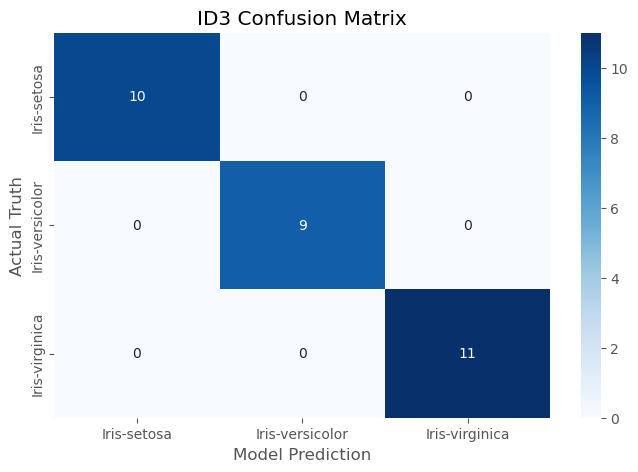

--- Detailed Classification Report ---
Class: Iris-setosa     | Precision: 1.00 | Recall: 1.00 | F1-Score: 1.00
Class: Iris-versicolor | Precision: 1.00 | Recall: 1.00 | F1-Score: 1.00
Class: Iris-virginica  | Precision: 1.00 | Recall: 1.00 | F1-Score: 1.00


In [6]:
y_pred = tree.predict(X_test)
classes = np.unique(y_test)

# Manual Confusion Matrix
cm = np.zeros((len(classes), len(classes)), dtype=int)
class_to_idx = {c: i for i, c in enumerate(classes)}
for true, pred in zip(y_test, y_pred):
    cm[class_to_idx[true], class_to_idx[pred]] += 1

accuracy = np.sum(np.diag(cm)) / np.sum(cm)
print(f"Overall Accuracy: {accuracy * 100:.2f}%\n")

# Plot Matrix
plt.figure(figsize=(8,5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes, cmap='Blues')
plt.xlabel('Model Prediction')
plt.ylabel('Actual Truth')
plt.title('ID3 Confusion Matrix')
plt.show()

# Advanced Metrics Calculation
print("--- Detailed Classification Report ---")
for i, c in enumerate(classes):
    tp = cm[i, i]
    fp = np.sum(cm[:, i]) - tp
    fn = np.sum(cm[i, :]) - tp
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    print(f"Class: {c:15} | Precision: {precision:.2f} | Recall: {recall:.2f} | F1-Score: {f1:.2f}")


## 6. Interactive Classification Module
**Requirement Fulfilled:** "After generating your tree, you must be able to apply your tree to new examples and classify them appropriately."

Change the variables in the cell below to simulate measurements of a new flower. Execute the cell to see how the ID3 model classifies it.

In [7]:
# ==========================================
# USER INPUT AREA
# Change these 4 values to test manually
# ==========================================
sepal_length = 6.0  # (Range: 4.0 to 8.0)
sepal_width  = 3.0  # (Range: 2.0 to 4.5)
petal_length = 4.8  # (Range: 1.0 to 7.0)
petal_width  = 1.8  # (Range: 0.1 to 2.5)
# ==========================================

# The algorithm transforms your input into a compatible array
new_example = np.array([[sepal_length, sepal_width, petal_length, petal_width]])

# Use the tree generated in step 4 to predict the outcome
prediction = tree.predict(new_example)[0]

print("+" + "-"*50 + "+")
print("| MANUAL SAMPLE ANALYSIS")
print("+" + "-"*50 + "+")
print(f"| Input Measurements:")
print(f"|   Sepal Length : {sepal_length} cm")
print(f"|   Sepal Width  : {sepal_width} cm")
print(f"|   Petal Length : {petal_length} cm")
print(f"|   Petal Width  : {petal_width} cm")
print("|")
print(f"| >>> ID3 CLASSIFICATION: {prediction.upper()} <<<")
print("+" + "-"*50 + "+")

+--------------------------------------------------+
| MANUAL SAMPLE ANALYSIS
+--------------------------------------------------+
| Input Measurements:
|   Sepal Length : 6.0 cm
|   Sepal Width  : 3.0 cm
|   Petal Length : 4.8 cm
|   Petal Width  : 1.8 cm
|
| >>> ID3 CLASSIFICATION: IRIS-VIRGINICA <<<
+--------------------------------------------------+
